In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
n = 1000

# Education → Income with realistic but skewed probabilities
# Every education level has a non-zero chance of any income bracket
# Format: [Low, Medium, High]

education_income_probs = {
    'High School': [0.65, 0.30, 0.05],   # Mostly low, but some can break through
    'Bachelor':    [0.20, 0.55, 0.25],   # Middle-heavy
    'Master':      [0.08, 0.42, 0.50],   # Skewed high, but life happens
    'PhD':         [0.05, 0.25, 0.70],   # Mostly high, but adjuncts exist 
}

income_brackets = ['Low', 'Medium', 'High']

# create education array, with the 4 education levels with the probabilities of occurrence
education = np.random.choice(
    ['High School', 'Bachelor', 'Master', 'PhD'], 
    n, 
    p=[0.35, 0.40, 0.18, 0.07]
)

# loop through 
income = np.array([
    np.random.choice(income_brackets, p=education_income_probs[e]) 
    for e in education
])

df = pd.DataFrame({'Education': education, 'Income': income})

In [3]:
df

,Education,Income
0,Bachelor,Low
1,PhD,High
2,Bachelor,High
3,Bachelor,Medium
4,High School,Medium
...,...,...
995,High School,Medium
996,Master,High
997,High School,Low
998,PhD,Medium


In [4]:
"""
MCAR
"""
perc_missing = round(n * 0.2)

df_missing = df.copy()
missing_idx = np.random.choice(n, perc_missing, replace=False)
df_missing.iloc[missing_idx, df_missing.columns.get_loc('Income')] = np.nan

print(f"Missing values in Income: {df_missing['Income'].isna().sum()} ({perc_missing/n:.0%})")

Missing values in Income: 200 (20%)


In [5]:
# fills the missing values with mode of the values in column
def mode_imputation(df_miss):
    df_res = df_miss.copy()
    mode_val = df_res['Income'].mode()[0]
    df_res['Income'] = df_res['Income'].fillna(mode_val)
    return df_res

In [6]:
# Instead of filling missing Income with the global most frequent value, 
# we fill it with the most frequent Income within each Education group

def grouped_mode_imputation(df_miss):
    df_res = df_miss.copy()
    # group all rows by Education, then look at Income within each group
    # transform - apply a function to each group but return result in the same shape as the original dataframe (one value per row)
    group_mode = df_res.groupby('Education')['Income'].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mode())
    )
    df_res['Income'] = df_res['Income'].fillna(group_mode)
    return df_res

In [7]:
def knn_imputation(df_miss, k=5):
    df_res = df_miss.copy()
    
    le_edu = LabelEncoder()
    le_inc = LabelEncoder()
    
    # Encode education (no missing)
    df_res['Education_enc'] = le_edu.fit_transform(df_res['Education'])
    
    # encode income — handle NaN separately
    # else we get the error - Classification metrics can't handle a mix of multiclass and unknown targets
    known_mask = df_res['Income'].notna()
    df_res.loc[known_mask, 'Income_enc'] = le_inc.fit_transform(df_res.loc[known_mask, 'Income'])
    
    imputer = KNNImputer(n_neighbors=k)
    # fit_transform returns a plain numpy array, ALL NaNs filled
    imputed_arr = imputer.fit_transform(df_res[['Education_enc', 'Income_enc']])
    
    # extract only the income column
    # round back to valid class indices, minimum and maximum numbers being 0 and len(le_inc.classes_) - 1
    income_enc_imputed = np.clip(np.round(imputed_arr[:, 1]).astype(int), 
                                  0, len(le_inc.classes_) - 1)
    
    # decode back to the income classes
    df_res['Income'] = le_inc.inverse_transform(income_enc_imputed)
    
    return df_res[['Education', 'Income']]

In [8]:
def logistic_regression_imputation(df_miss):
    df_res = df_miss.copy()
    
    le_edu = LabelEncoder()
    df_res['Education_enc'] = le_edu.fit_transform(df_res['Education'])
    
    train_mask = df_res['Income'].notna()
    test_mask  = df_res['Income'].isna()
    
    X_train = df_res.loc[train_mask, ['Education_enc']]
    y_train = df_res.loc[train_mask, 'Income']
    X_test  = df_res.loc[test_mask,  ['Education_enc']]
    
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train, y_train)
    
    df_res.loc[test_mask, 'Income'] = clf.predict(X_test)
    return df_res[['Education', 'Income']]

In [9]:
def evaluate_categorical_imputations(df_true, df_missing, target_col='Income'):
    missing_mask = df_missing[target_col].isna()
    missing_idx  = df_missing.index[missing_mask]
    y_true = df_true.loc[missing_idx, target_col]
    
    methods = {
        'Mode':                mode_imputation(df_missing),
        'Grouped Mode':        grouped_mode_imputation(df_missing),
        'KNN (k=5)':           knn_imputation(df_missing, k=5),
        'Logistic Regression': logistic_regression_imputation(df_missing),
    }
    
    results = []
    confusion_matrices = {}
    
    for name, df_imputed in methods.items():
        y_pred = df_imputed.loc[missing_idx, target_col]
        
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average='weighted')
        cm  = confusion_matrix(y_true, y_pred, labels=['Low', 'Medium', 'High'])
        
        results.append({'Method': name, 'Accuracy': acc, 'F1 (weighted)': f1})
        confusion_matrices[name] = cm
    
    results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False)
    return results_df, confusion_matrices

In [10]:
results_df, confusion_matrices = evaluate_categorical_imputations(df, df_missing)
print("\n=== Performance Ranking ===")
print(results_df.round(4).to_string(index=False))


=== Performance Ranking ===
             Method  Accuracy  F1 (weighted)
       Grouped Mode     0.605         0.6071
Logistic Regression     0.515         0.4271
          KNN (k=5)     0.310         0.3133
               Mode     0.365         0.1952


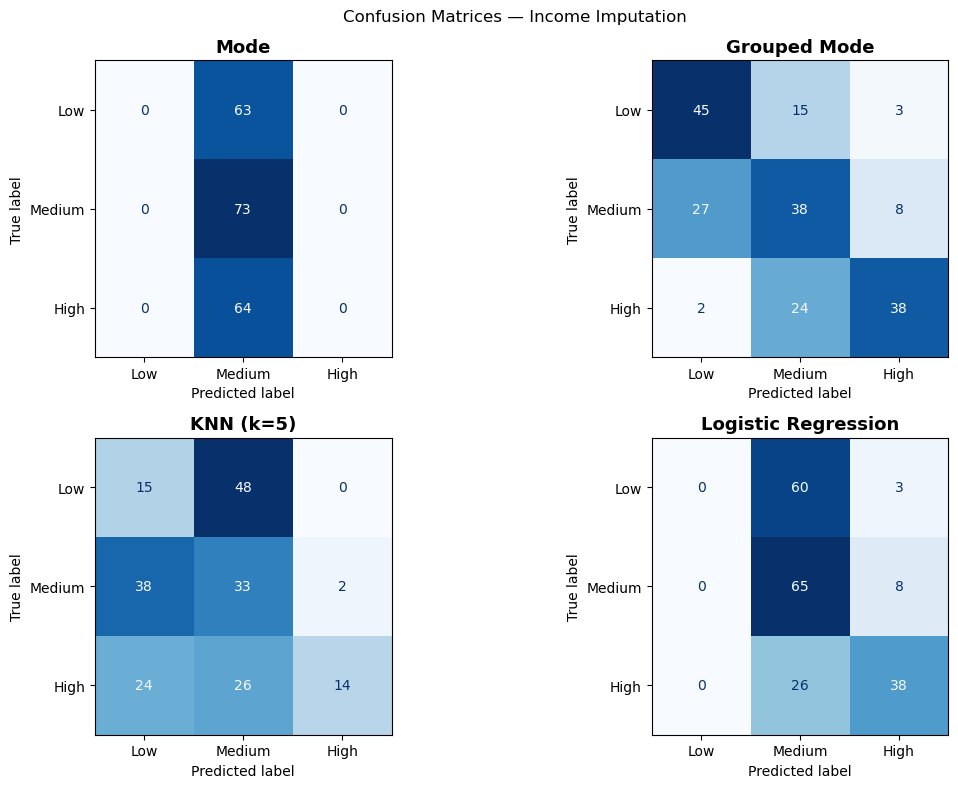

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
labels = ['Low', 'Medium', 'High']

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}", fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Income Imputation', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
"""
MAR
"""
# Simulate a more realistic employee dataset
# 4 features, each with a plausible real-world relationship

np.random.seed(42)
n = 1000

# 1. Age
age = np.random.randint(22, 65, n)

# 2. Education
education = np.random.choice(
    ['High School', 'Bachelor', 'Master', 'PhD'],
    n, p=[0.35, 0.40, 0.18, 0.07]
)

# 3. Years of Experience (loosely tied to age)
experience = np.clip(
    (age - 22) * np.random.uniform(0.4, 0.9, n) + np.random.normal(0, 2, n),
    0, 40
).astype(int)

# 4. Income — depends on BOTH education AND experience
education_base = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
edu_score = np.array([education_base[e] for e in education])

income_score = edu_score * 0.5 + (experience / 10) * 0.5 + np.random.normal(0, 0.5, n)

income = np.select(
    [income_score < 1.0, income_score < 2.0, income_score >= 2.0],
    ['Low','Medium','High'],
    default=''
)

df = pd.DataFrame({
    'Age':        age,
    'Education':  education,
    'Experience': experience,
    'Income':     income
})

In [17]:
# Older employees → less likely to disclose income (privacy concerns)
# This is MAR because Age is observed and drives the missingness
# but Age is NOT the only thing predicting Income

age_normalized = (df['Age'] - df['Age'].min()) / (df['Age'].max() - df['Age'].min())
missing_probs = 0.05 + 0.30 * age_normalized   # ranges from 5% to 35%

mar_mask = np.random.binomial(1, missing_probs).astype(bool)
df_mar = df.copy()
df_mar.loc[mar_mask, 'Income'] = np.nan

print(f"Total missing: {df_mar['Income'].isna().sum()} ({mar_mask.mean():.0%})")

Total missing: 199 (20%)
